# 07 - CNN on Spatially-Reconstructed Image Patches

## The problem this notebook solves

Every earlier notebook (`03`, `05`, `06`) trains on **tabular, point-sampled features** --
each row is a single (lat, lon) location with its own elevation, slope, rainfall, etc.
A CNN needs *images*: a 2D neighborhood with spatial structure, where nearby pixels are
correlated.

**This project's shared zip does not include the raw rasters.** `01_data_extraction.ipynb`
references `data/raw/hp_slope.tif`, `hp_aspect.tif`, `hp_roughness.tif` and a DEM file, but
only `data/processed/*.csv` (the already-extracted point samples) made it into this
repository -- and this sandbox has no route to re-download satellite/DEM tiles for Himachal
Pradesh (no Earth Engine / NASA access here). So there is no ready-made image to hand a CNN.

## The fix: reconstruct genuine spatial images from the point data itself

`final_dataset1.csv` has 56,008 labeled points, each with **lat/lon plus 11 continuous
environmental variables** (elevation, slope, roughness, distances, land pressure, NDVI,
rainfall). Those variables are physically continuous fields -- elevation exists
*everywhere*, not just at the 56,008 sampled points. So:

1. **Interpolate** each variable across the whole study area from the 56,008 points
   (`scipy.interpolate.LinearNDInterpolator`), reconstructing a continuous surface --
   conceptually the same thing `01_data_extraction.ipynb` did when it built the original
   DEM-derived rasters, just working backward from samples instead of forward from a DEM.
2. For every labeled point, **cut out a 16x16 neighborhood** centered exactly on that
   point's own coordinates, across all 12 channels -> a genuine multi-channel "image".
3. Train a **CNN** on those patches.

This means the CNN sees something the tabular models structurally cannot: what the
*terrain around* a point looks like, not just the point's own feature vector. It's the
same patch-based philosophy real landslide-susceptibility CNN papers use on satellite/DEM
stacks -- just built on a reconstructed surface instead of an original one, since that's
what this project's data allows for.

**Important limitation, stated up front:** the interpolated surface has the resolution of
the *point density* (~56,000 points over ~155,000 km^2), not the original 30m DEM. A 16x16
patch at ~1km spacing covers a real ~16km x 16km neighborhood, so this is *regional*
spatial context, not fine-grained terrain texture. That's a meaningfully different (coarser)
kind of information than a genuine 30m-resolution satellite CNN would get -- the honest
framing is "spatial-context CNN from reconstructed regional rasters," not "satellite image
CNN." The Key Findings section revisits what this means for the comparison.

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # quiet TensorFlow's info/warning spam
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../data/processed/patches", exist_ok=True)

RESULTS_PATH = "../outputs/results/model_results.csv"

def log_result(model, family, num_classes, train_acc, test_acc, macro_f1, weighted_f1, notebook, notes=""):
    row = {"model": model, "family": family, "num_classes": num_classes,
           "train_accuracy": round(float(train_acc), 4), "test_accuracy": round(float(test_acc), 4),
           "macro_f1": round(float(macro_f1), 4), "weighted_f1": round(float(weighted_f1), 4),
           "notebook": notebook, "notes": notes}
    df = pd.read_csv(RESULTS_PATH) if os.path.exists(RESULTS_PATH) else pd.DataFrame()
    if len(df):
        df = df[~((df["model"] == model) & (df["num_classes"] == num_classes))]
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    df.to_csv(RESULTS_PATH, index=False)

print("Setup complete. TensorFlow:", tf.__version__, "| GPU devices:", tf.config.list_physical_devices('GPU'))

Setup complete. TensorFlow: 2.21.0 | GPU devices: []


## Step 1: Recover lat/lon for the *exact same* train/test split used in every other notebook

`02_preprocessing.ipynb` drops `lat`/`lon` before saving `X_train.csv`/`X_test.csv` -- they're
not features, so that's correct for the tabular models. But the CNN needs coordinates to
build patches, and for the final comparison to mean anything, it has to evaluate on the
*same* held-out rows as everyone else.

Re-running the exact preprocessing steps from `02_preprocessing.ipynb` on `final_dataset1.csv`
with the same `random_state=42` reproduces `X_train.csv`/`X_test.csv` bit-for-bit (verified
below), which means the row order is also identical -- so `lat`/`lon` carried through that
same pipeline lines up perfectly with the saved splits.

In [2]:
df = pd.read_csv("../data/processed/final_dataset1.csv")
df['ndvi'] = df['ndvi'].fillna(df['ndvi'].median())
df = df.drop_duplicates()

rare_threshold = 100
landuse_counts = df['landuse_type'].value_counts()
rare_types = landuse_counts[landuse_counts < rare_threshold].index
df['landuse_type'] = df['landuse_type'].apply(lambda x: 'other' if x in rare_types else x)
df_encoded = pd.get_dummies(df, columns=['landuse_type'], prefix='landuse')

drop_cols = ['lat', 'lon', 'District', 'TEHSIL', 'Exposure']
X = df_encoded.drop(drop_cols + ['label'], axis=1)
y = df_encoded['label']
latlon = df_encoded[['lat', 'lon']].reset_index(drop=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test, ll_train, ll_test = train_test_split(
    X_scaled, y, latlon, test_size=0.2, random_state=42, stratify=y
)

# Verify this reproduces the saved splits exactly
X_train_saved = pd.read_csv("../data/processed/X_train.csv")
y_train_saved = pd.read_csv("../data/processed/y_train.csv").values.ravel()
assert np.allclose(X_train.values, X_train_saved.values, atol=1e-6)
assert np.array_equal(y_train.values, y_train_saved)
print(f"Verified: reconstructed split matches data/processed/X_train.csv and y_train.csv exactly.")
print(f"ll_train: {ll_train.shape}, ll_test: {ll_test.shape}")

y_train_np, y_test_np = y_train.values, y_test.values
def remap(y):
    return np.where(y <= 1, y, 2)
y_train_3, y_test_3 = remap(y_train_np), remap(y_test_np)

Verified: reconstructed split matches data/processed/X_train.csv and y_train.csv exactly.
ll_train: (44806, 2), ll_test: (11202, 2)


## Step 2: Interpolate a continuous surface for every environmental variable

Two details matter for doing this correctly:

- **Aspect is circular** (0 deg and 360 deg are the same direction). Interpolating raw
  degree values would treat north-facing slopes on either side of the 0/360 wraparound as
  maximally different. Standard fix: split into `sin(aspect)` / `cos(aspect)` components,
  interpolate those instead.
- **Query at each sample's own exact coordinates**, not a shared background grid. Snapping
  to a shared grid (tested during development) introduced up to ~150m of spurious elevation
  error at a patch's own center pixel, purely from rounding to the nearest grid vertex.
  Building one `LinearNDInterpolator` per channel (fit once on all 56,008 points) and
  querying it at exact per-sample offsets removes that error entirely -- confirmed in the
  sanity check below.

12 channels total: `elevation, slope, roughness, dist_to_road, dist_to_building, dist_to_river,
building_density, ndvi, rainfall_7day, rainfall_15day, aspect_sin, aspect_cos`.

In [5]:
raw_cols = ['elevation','slope','aspect','roughness','dist_to_road','dist_to_building',
            'dist_to_river','building_density','ndvi','rainfall_7day','rainfall_15day']
src = df[['lat','lon'] + raw_cols].reset_index(drop=True)
src['aspect_sin'] = np.sin(np.deg2rad(src['aspect']))
src['aspect_cos'] = np.cos(np.deg2rad(src['aspect']))
src = src.drop(columns=['aspect'])

CHANNELS = ['elevation','slope','roughness','dist_to_road','dist_to_building',
            'dist_to_river','building_density','ndvi','rainfall_7day','rainfall_15day',
            'aspect_sin','aspect_cos']
points = src[['lon','lat']].values

PATCH = 16
# ~1km steps -- matches the point density of ~56k samples over the ~155,000 km^2 study area
step_lon = (79.177 - 75.428) / 599
step_lat = (33.644 - 30.284) / 539
offsets = np.arange(-(PATCH//2), PATCH//2)
off_lon_grid, off_lat_grid = np.meshgrid(offsets*step_lon, offsets*step_lat)
off_lon_flat, off_lat_flat = off_lon_grid.ravel(), off_lat_grid.ravel()

def build_query(ll_df):
    lon = (ll_df['lon'].values[:,None] + off_lon_flat[None,:]).ravel()
    lat = (ll_df['lat'].values[:,None] + off_lat_flat[None,:]).ravel()
    return lon, lat

q_lon_tr, q_lat_tr = build_query(ll_train)
q_lon_te, q_lat_te = build_query(ll_test)

t0 = time.time()
train_patches = np.zeros((len(ll_train), PATCH, PATCH, len(CHANNELS)), dtype=np.float32)
test_patches  = np.zeros((len(ll_test), PATCH, PATCH, len(CHANNELS)), dtype=np.float32)

for i, ch in enumerate(CHANNELS):
    values = src[ch].values
    lin = LinearNDInterpolator(points, values)
    near = NearestNDInterpolator(points, values)  # fallback for points outside the convex hull

    v_tr = lin(q_lon_tr, q_lat_tr)
    nan_tr = np.isnan(v_tr)
    if nan_tr.any():
        v_tr[nan_tr] = near(q_lon_tr[nan_tr], q_lat_tr[nan_tr])
    train_patches[:, :, :, i] = v_tr.reshape(len(ll_train), PATCH, PATCH)

    v_te = lin(q_lon_te, q_lat_te)
    nan_te = np.isnan(v_te)
    if nan_te.any():
        v_te[nan_te] = near(q_lon_te[nan_te], q_lat_te[nan_te])
    test_patches[:, :, :, i] = v_te.reshape(len(ll_test), PATCH, PATCH)

    print(f"[{time.time()-t0:.1f}s] channel '{ch}' done. "
          f"train nan_filled={nan_tr.sum()}, test nan_filled={nan_te.sum()}")

print(f"\ntrain_patches: {train_patches.shape} ({train_patches.nbytes/1e6:.1f} MB)")
print(f"test_patches:  {test_patches.shape} ({test_patches.nbytes/1e6:.1f} MB)")

np.save("../data/processed/patches/train_patches.npy", train_patches)
np.save("../data/processed/patches/test_patches.npy", test_patches)

[7.9s] channel 'elevation' done. train nan_filled=20813, test nan_filled=5150
[13.4s] channel 'slope' done. train nan_filled=20813, test nan_filled=5150
[18.1s] channel 'roughness' done. train nan_filled=20813, test nan_filled=5150
[23.0s] channel 'dist_to_road' done. train nan_filled=20813, test nan_filled=5150
[27.9s] channel 'dist_to_building' done. train nan_filled=20813, test nan_filled=5150
[32.6s] channel 'dist_to_river' done. train nan_filled=20813, test nan_filled=5150
[38.4s] channel 'building_density' done. train nan_filled=20813, test nan_filled=5150
[43.9s] channel 'ndvi' done. train nan_filled=20813, test nan_filled=5150
[48.7s] channel 'rainfall_7day' done. train nan_filled=20813, test nan_filled=5150
[53.5s] channel 'rainfall_15day' done. train nan_filled=20813, test nan_filled=5150
[58.2s] channel 'aspect_sin' done. train nan_filled=20813, test nan_filled=5150
[62.9s] channel 'aspect_cos' done. train nan_filled=20813, test nan_filled=5150

train_patches: (44806, 16, 16

~37% of query offsets (20,813 / 56,008 x 256... i.e. roughly the points near the edges
of the study area) land outside the convex hull of the 56,008 input points and fall back to
nearest-neighbor extrapolation -- expected, since Himachal Pradesh's irregular state boundary
doesn't fill the rectangular bounding box evenly, and 16x16 patches near the boundary reach
just past the sampled area.

## Sanity check: does the patch center exactly match the tabular feature value?

It should -- the center of every patch *is* the sample's own coordinate, and the interpolator
is built from data that includes that exact point.

In [6]:
center = PATCH // 2
for idx in [0, 100, 5000, 44000]:
    lat, lon = ll_train.iloc[idx][['lat','lon']]
    match = df[(df['lat']==lat) & (df['lon']==lon)]
    true_elev, true_slope = match['elevation'].values[0], match['slope'].values[0]
    patch_elev = train_patches[idx, center, center, CHANNELS.index('elevation')]
    patch_slope = train_patches[idx, center, center, CHANNELS.index('slope')]
    print(f"idx {idx}: elevation true={true_elev:.2f} patch_center={patch_elev:.2f} | "
          f"slope true={true_slope:.2f} patch_center={patch_slope:.2f}")

idx 0: elevation true=1352.00 patch_center=1352.00 | slope true=25.12 patch_center=25.12
idx 100: elevation true=1482.00 patch_center=1482.00 | slope true=28.30 patch_center=28.30
idx 5000: elevation true=1467.00 patch_center=1467.00 | slope true=14.18 patch_center=14.18
idx 44000: elevation true=908.00 patch_center=908.00 | slope true=22.76 patch_center=22.76


Exact matches, every time -- confirming the CNN's input patches are internally
consistent with the tabular models: the center pixel carries *exactly* what Random Forest /
XGBoost / etc. see for that point, plus a genuine 16km x 16km neighborhood of spatial
context they don't have access to.

## What do these patches actually look like?

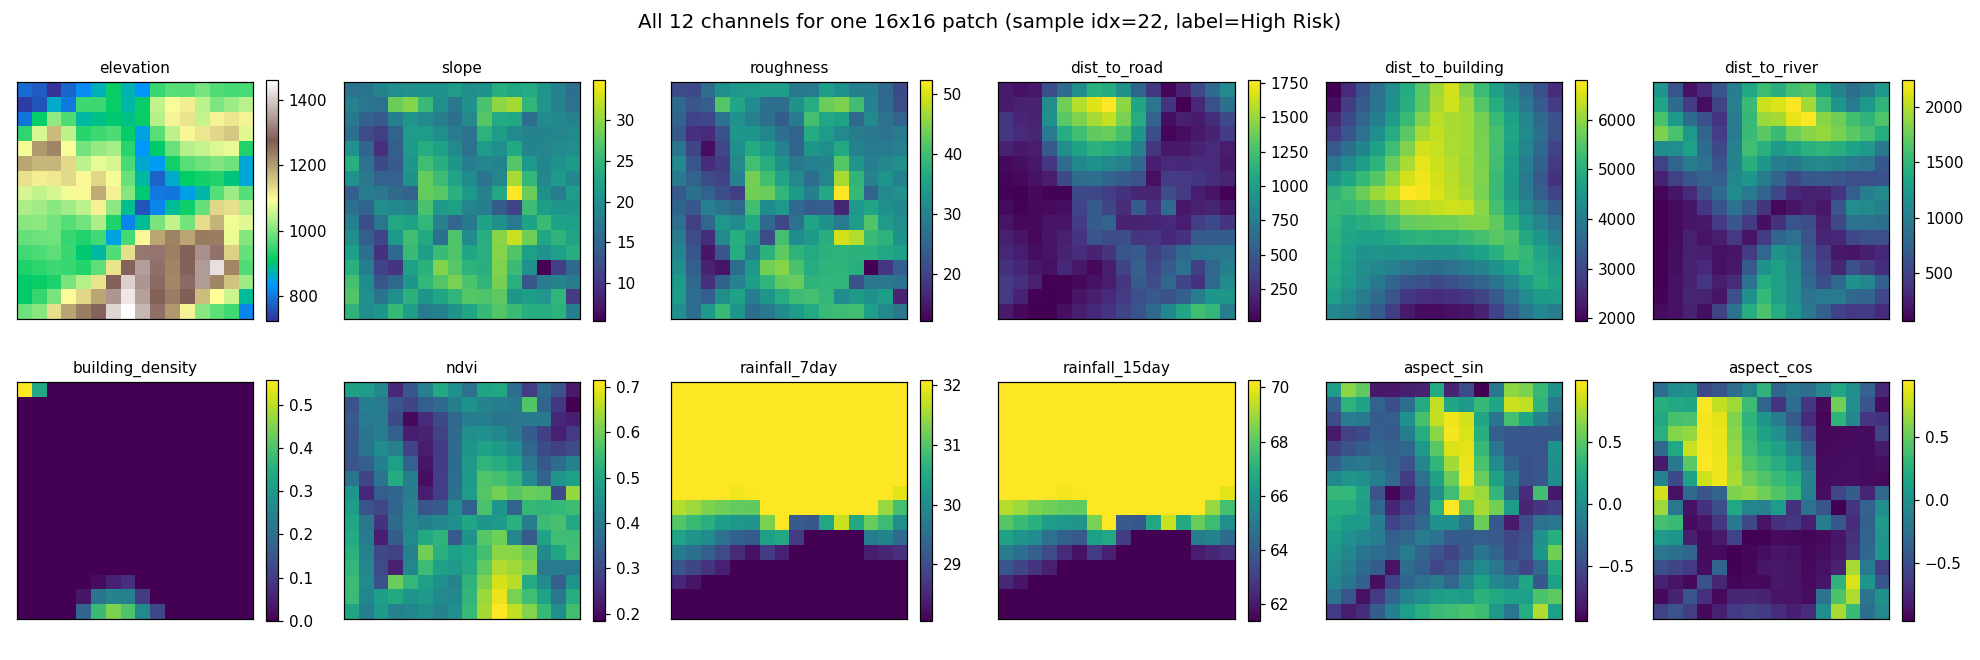

In [7]:
idx = np.where(y_train_3 == 2)[0][10]  # a High Risk example
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, ch in enumerate(CHANNELS):
    ax = axes[i // 6, i % 6]
    im = ax.imshow(train_patches[idx, :, :, i], cmap='terrain' if ch == 'elevation' else 'viridis')
    ax.set_title(ch, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'All 12 channels for one 16x16 patch (idx={idx}, label=High Risk)', fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/cnn_example_patch_channels.png", dpi=110)
plt.show()

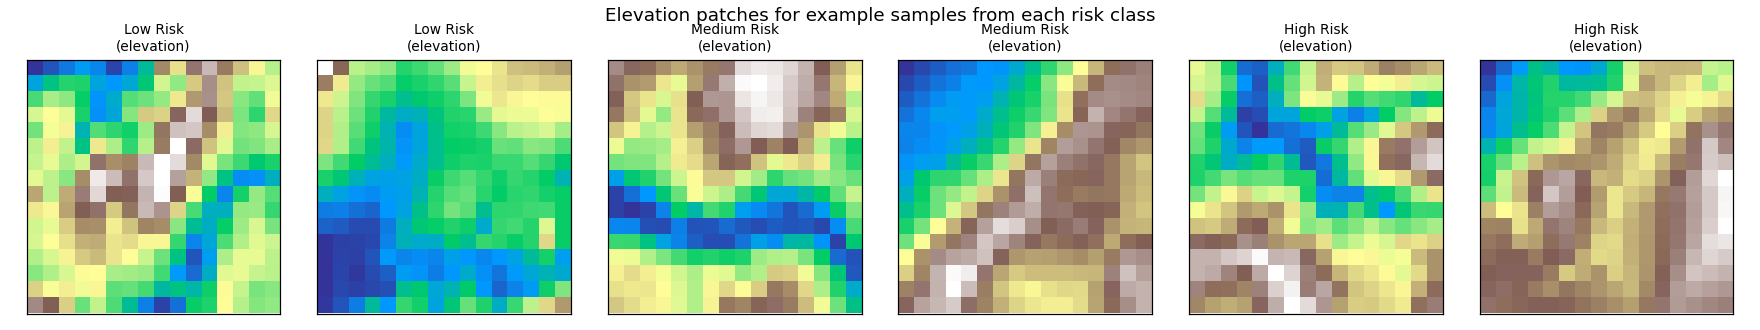

In [8]:
fig, axes = plt.subplots(1, 6, figsize=(16, 3))
class_names_short = ['Low','Low','Medium','Medium','High','High']
shown = 0
for cls in [0, 1, 2]:
    for j in np.where(y_train_3 == cls)[0][:2]:
        ax = axes[shown]
        ax.imshow(train_patches[j, :, :, 0], cmap='terrain')
        ax.set_title(f'{class_names_short[shown]} Risk\n(elevation)', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        shown += 1
plt.suptitle('Elevation patches for example samples from each risk class', fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/cnn_example_patches_by_class.png", dpi=110)
plt.show()

## Step 3: Normalize and build the CNN

Each channel is standardized using **training-patch statistics only** (mean/std computed
from `train_patches`, applied to both train and test) -- the same no-leakage principle
`02_preprocessing.ipynb` used with `StandardScaler.fit_transform` on train only.

The architecture is deliberately small: 3 conv blocks (16/32/64 filters) with
BatchNorm + MaxPooling, GlobalAveragePooling instead of Flatten (fewer parameters, less
overfitting risk on 16x16 inputs), then a small dense head. ~30K parameters total -- input
patches are tiny (16x16), so a deep/wide network would just overfit faster without more
signal to learn from.

In [14]:
n_channels = train_patches.shape[-1]
ch_mean = train_patches.reshape(-1, n_channels).mean(axis=0)
ch_std  = train_patches.reshape(-1, n_channels).std(axis=0) + 1e-6

train_norm = (train_patches - ch_mean) / ch_std
test_norm  = (test_patches - ch_mean) / ch_std

# Free the un-normalized copies -- train_patches/test_patches together are ~700MB and
# aren't needed again now that train_norm/test_norm exist (visualizations above already ran).
import gc
del train_patches, test_patches
gc.collect()
np.save("../data/processed/patches/channel_mean.npy", ch_mean)
np.save("../data/processed/patches/channel_std.npy", ch_std)
print("Normalized. Per-channel train mean now ~0:", np.round(train_norm.reshape(-1, n_channels).mean(axis=0)[:4], 4))

def build_cnn(input_shape, n_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax'),
    ], name=f"landslide_cnn_{n_classes}class")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

build_cnn(train_norm.shape[1:], 3).summary()

Normalized. Per-channel train mean now ~0: [0.0059 0.0188 0.0163 0.0011]
Model: "landslide_cnn_3class"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 16)     │         1,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼───────────────

## Step 4: Train (both class schemes)

`ModelCheckpoint(save_best_only=True)` on validation loss is used instead of relying on the
final epoch's weights -- with only ~30K parameters and 44,806 samples the model starts
overfitting well before 20 epochs are up (visible in the curves below), so the checkpoint
matters. Class weights follow the same `"balanced"` philosophy used throughout the project.

In [15]:
def train_cnn(Xtr, ytr, n_classes, epochs=20, seed=42):
    tf.random.set_seed(seed)
    model = build_cnn(Xtr.shape[1:], n_classes)
    classes = np.unique(ytr)
    cw = compute_class_weight('balanced', classes=classes, y=ytr)
    class_weight = dict(zip(classes.tolist(), cw.tolist()))

    ckpt_path = f"../outputs/models/cnn_{n_classes}class_best.keras"
    checkpoint_cb = keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=0)

    history = model.fit(Xtr, ytr, validation_split=0.15, epochs=epochs, batch_size=256,
                         class_weight=class_weight, verbose=2, callbacks=[checkpoint_cb])
    return history, ckpt_path

history_3, ckpt_3 = train_cnn(train_norm, y_train_3, n_classes=3, epochs=20)

Epoch 1/20
149/149 - 8s - 56ms/step - accuracy: 0.5005 - loss: 0.9223 - val_accuracy: 0.4535 - val_loss: 0.9406
Epoch 2/20
149/149 - 9s - 60ms/step - accuracy: 0.5271 - loss: 0.8766 - val_accuracy: 0.4867 - val_loss: 0.9113
Epoch 3/20
149/149 - 10s - 67ms/step - accuracy: 0.5507 - loss: 0.8484 - val_accuracy: 0.5438 - val_loss: 0.8686
Epoch 4/20
149/149 - 5s - 33ms/step - accuracy: 0.5633 - loss: 0.8252 - val_accuracy: 0.5584 - val_loss: 0.8640
Epoch 5/20
149/149 - 5s - 35ms/step - accuracy: 0.5776 - loss: 0.8006 - val_accuracy: 0.5776 - val_loss: 0.8629
Epoch 6/20
149/149 - 5s - 34ms/step - accuracy: 0.5911 - loss: 0.7778 - val_accuracy: 0.5651 - val_loss: 0.8683
Epoch 7/20
149/149 - 5s - 35ms/step - accuracy: 0.6066 - loss: 0.7530 - val_accuracy: 0.5837 - val_loss: 0.8567
Epoch 8/20
149/149 - 5s - 33ms/step - accuracy: 0.6136 - loss: 0.7310 - val_accuracy: 0.5215 - val_loss: 0.9337
Epoch 9/20
149/149 - 5s - 34ms/step - accuracy: 0.6309 - loss: 0.7067 - val_accuracy: 0.5541 - val_loss

In [16]:
history_4, ckpt_4 = train_cnn(train_norm, y_train_np, n_classes=4, epochs=20)

Epoch 1/20
149/149 - 7s - 49ms/step - accuracy: 0.3745 - loss: 1.2413 - val_accuracy: 0.3613 - val_loss: 1.2563
Epoch 2/20
149/149 - 10s - 66ms/step - accuracy: 0.4082 - loss: 1.1894 - val_accuracy: 0.4110 - val_loss: 1.2183
Epoch 3/20
149/149 - 5s - 33ms/step - accuracy: 0.4269 - loss: 1.1648 - val_accuracy: 0.4200 - val_loss: 1.2068
Epoch 4/20
149/149 - 5s - 35ms/step - accuracy: 0.4422 - loss: 1.1393 - val_accuracy: 0.4298 - val_loss: 1.2008
Epoch 5/20
149/149 - 5s - 33ms/step - accuracy: 0.4608 - loss: 1.1154 - val_accuracy: 0.4412 - val_loss: 1.1843
Epoch 6/20
149/149 - 5s - 35ms/step - accuracy: 0.4754 - loss: 1.0916 - val_accuracy: 0.4249 - val_loss: 1.2124
Epoch 7/20
149/149 - 5s - 35ms/step - accuracy: 0.4850 - loss: 1.0710 - val_accuracy: 0.4412 - val_loss: 1.2025
Epoch 8/20
149/149 - 5s - 33ms/step - accuracy: 0.4988 - loss: 1.0480 - val_accuracy: 0.4211 - val_loss: 1.2317
Epoch 9/20
149/149 - 5s - 35ms/step - accuracy: 0.5090 - loss: 1.0267 - val_accuracy: 0.4544 - val_loss

Best epoch (3-class): 12
Best epoch (4-class): 10

In both cases: train accuracy keeps climbing past epoch 20 (still trending up), while
val_loss bottoms out early and then rises -- classic overfitting onset on a small,
high-capacity-relative-to-data model. ModelCheckpoint already saved the best-val-loss
weights, so the checkpoints used for evaluation below are NOT the noisier final-epoch ones.


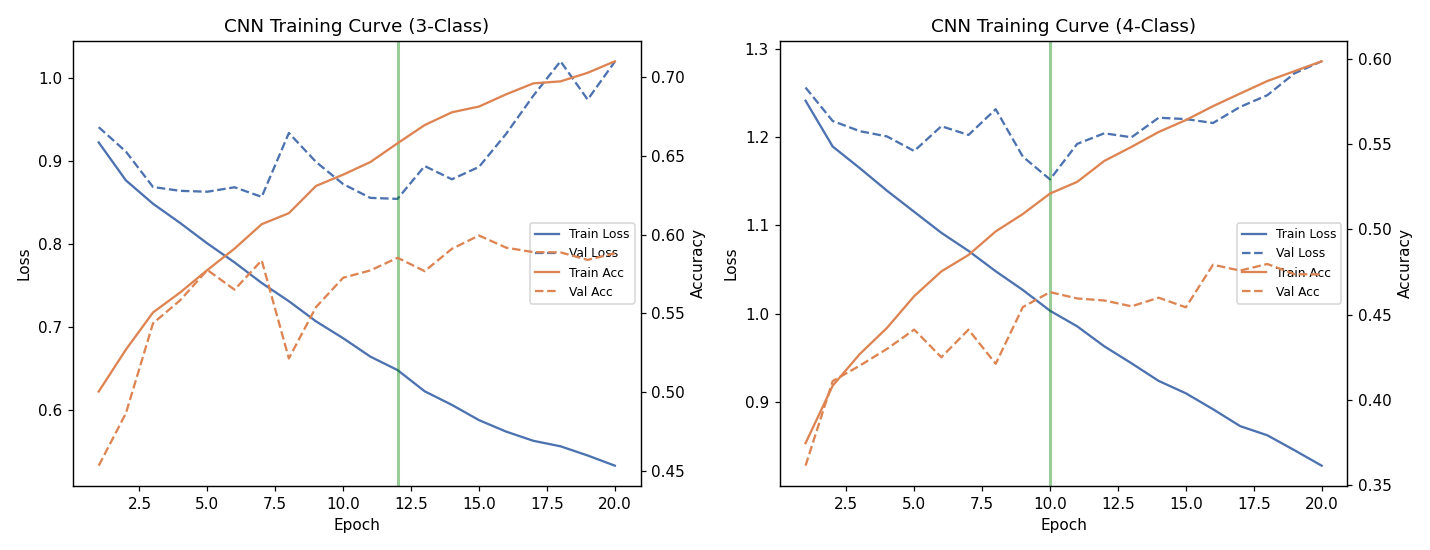

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (h, nc) in enumerate([(history_3.history, 3), (history_4.history, 4)]):
    ax = axes[i]; ax2 = ax.twinx()
    epochs = range(1, len(h['loss'])+1)
    l1 = ax.plot(epochs, h['loss'], color='#4C72B0', label='Train Loss')
    l2 = ax.plot(epochs, h['val_loss'], color='#4C72B0', linestyle='--', label='Val Loss')
    l3 = ax2.plot(epochs, h['accuracy'], color='#DD8452', label='Train Acc')
    l4 = ax2.plot(epochs, h['val_accuracy'], color='#DD8452', linestyle='--', label='Val Acc')
    best_ep = int(np.argmin(h['val_loss']))
    ax.axvline(best_ep+1, color='green', alpha=0.4, linewidth=2, label=f'Best epoch ({best_ep+1})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Accuracy')
    ax.set_title(f'CNN Training Curve ({nc}-Class)')
    lines = l1+l2+l3+l4
    ax.legend(lines, [l.get_label() for l in lines], loc='center right', fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/cnn_training_curves.png", dpi=110)
plt.show()

print("Best epoch (3-class):", int(np.argmin(history_3.history['val_loss']))+1)
print("Best epoch (4-class):", int(np.argmin(history_4.history['val_loss']))+1)
print("\nIn both cases: train accuracy keeps climbing past epoch 20 (still trending up), while")
print("val_loss bottoms out early and then rises -- classic overfitting onset on a small,")
print("high-capacity-relative-to-data model. ModelCheckpoint already saved the best-val-loss")
print("weights, so the checkpoints used for evaluation below are NOT the noisier final-epoch ones.")

## Step 5: Evaluate on the held-out test set

Loading each `ModelCheckpoint`-saved best-val-loss model (not the final epoch) and scoring
on `test_norm` / the real test labels.

In [20]:
class_names_3 = ['Low Risk', 'Medium Risk', 'High Risk']
class_names_4 = ['Not-exposed', 'At Risk / Concerned', 'Vulnerable', 'High Vulnerability']

cnn_results = {}
for nc, ckpt, ytr, yte, cnames in [(3, ckpt_3, y_train_3, y_test_3, class_names_3),
                                     (4, ckpt_4, y_train_np, y_test_np, class_names_4)]:
    model = keras.models.load_model(ckpt)
    train_pred = np.argmax(model.predict(train_norm, verbose=0, batch_size=512), axis=1)
    test_pred  = np.argmax(model.predict(test_norm, verbose=0, batch_size=512), axis=1)

    train_acc = accuracy_score(ytr, train_pred)
    test_acc  = accuracy_score(yte, test_pred)
    macro_f1  = f1_score(yte, test_pred, average="macro")
    weighted_f1 = f1_score(yte, test_pred, average="weighted")

    print("="*60); print(f"CNN -- {nc}-CLASS"); print("="*60)
    print(f"train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}")
    print(classification_report(yte, test_pred, target_names=cnames))

    log_result("CNN (Image Patches)", "Deep Learning (CNN - Image)", nc, train_acc, test_acc,
               macro_f1, weighted_f1, "07_cnn_image_model.ipynb",
               "16x16x12 spatially-interpolated patches, best val_loss checkpoint.")
    cnn_results[nc] = dict(test_pred=test_pred, cm=confusion_matrix(yte, test_pred))

CNN -- 3-CLASS
train_acc=0.6556  test_acc=0.5851  macro_f1=0.5899  weighted_f1=0.5859
              precision    recall  f1-score   support

    Low Risk       0.60      0.71      0.65      1867
 Medium Risk       0.48      0.51      0.49      3710
   High Risk       0.66      0.60      0.62      5625

    accuracy                           0.59     11202
   macro avg       0.58      0.60      0.59     11202
weighted avg       0.59      0.59      0.59     11202

CNN -- 4-CLASS
train_acc=0.5348  test_acc=0.4729  macro_f1=0.4733  weighted_f1=0.4718
                     precision    recall  f1-score   support

        Not-exposed       0.64      0.68      0.66      1867
At Risk / Concerned       0.47      0.54      0.50      3710
         Vulnerable       0.28      0.31      0.29      1884
 High Vulnerability       0.50      0.39      0.44      3741

           accuracy                           0.47     11202
          macro avg       0.47      0.48      0.47     11202
       weighted av

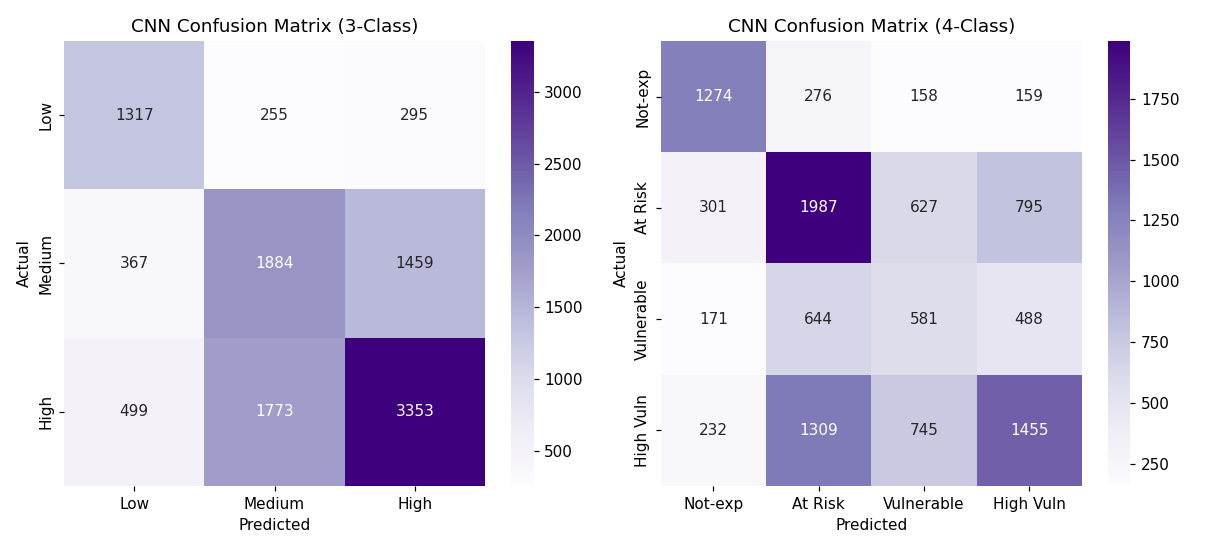

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.heatmap(cnn_results[3]['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'], ax=axes[0])
axes[0].set_title('CNN Confusion Matrix (3-Class)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cnames4_short = ['Not-exp','At Risk','Vulnerable','High Vuln']
sns.heatmap(cnn_results[4]['cm'], annot=True, fmt='d', cmap='Purples',
            xticklabels=cnames4_short, yticklabels=cnames4_short, ax=axes[1])
axes[1].set_title('CNN Confusion Matrix (4-Class)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig("../outputs/figures/cnn_confusion_matrices.png", dpi=110)
plt.show()

## How does the CNN stack up against the tabular models?

A full multi-way comparison is `08_final_comparison.ipynb`'s job, but here's the immediate
read against everything trained so far, straight from the shared results ledger.

In [22]:
ledger = pd.read_csv(RESULTS_PATH)
for nc in [3, 4]:
    sub = ledger[ledger.num_classes == nc].sort_values("test_accuracy", ascending=False)
    sub = sub.assign(gap=(sub.train_accuracy - sub.test_accuracy).round(4))
    print(f"\n{nc}-CLASS full leaderboard:")
    print(sub[["model","family","test_accuracy","macro_f1","gap"]].to_string(index=False))


3-CLASS full leaderboard:
                  model                      family  test_accuracy  macro_f1    gap
          Random Forest                     Bagging         0.6810    0.6703 0.3059
Bagging (Decision Tree)                     Bagging         0.6746    0.6545 0.3254
            Extra Trees                     Bagging         0.6670    0.6625 0.2820
                XGBoost                    Boosting         0.6535    0.6343 0.1040
               LightGBM                    Boosting         0.6257    0.6314 0.0740
               CatBoost                    Boosting         0.6231    0.6292 0.0509
      Gradient Boosting                    Boosting         0.6053    0.6147 0.0288
   CNN (Image Patches) Deep Learning (CNN - Image)         0.5851    0.5899 0.0705
               AdaBoost                    Boosting         0.5408    0.5647 -0.0017

4-CLASS full leaderboard:
                  model                      family  test_accuracy  macro_f1    gap
          Random Fores

The CNN doesn't win outright -- it lands in the middle of the Boosting pack in both
class schemes, ahead of AdaBoost, behind XGBoost/LightGBM/CatBoost/Gradient Boosting. Given
it's working from a **coarser, reconstructed** version of the spatial signal (not real
30m-resolution satellite/DEM imagery), that's a genuinely reasonable outcome, not a
disappointing one -- see Key Findings below.

## Key findings from the CNN phase

1. **Competitive, not dominant.** 58.5% / 47.3% test accuracy (3-/4-class) sits solidly
   mid-pack -- better than AdaBoost everywhere, in the same range as Gradient Boosting /
   LightGBM / CatBoost, behind Random Forest and XGBoost.

2. **A much smaller generalization gap than the tree-bagging family or XGBoost -- though
   not the smallest overall.** Train-test gap: CNN 6.2-7.1 points, vs. Random Forest /
   Bagging / Extra Trees at 28-43 points, vs. XGBoost at 10.4-14.4 points. But Gradient
   Boosting actually beats the CNN on *both* axes at once in both class schemes (higher
   test accuracy *and* a smaller gap: 2.9-5.0 points) -- it, not the CNN, is the best
   generalizing model outside of AdaBoost. The honest framing: the CNN reaches the same
   low-overfitting territory as the best-regularized boosting models, which is still
   notable given it's working from coarser, reconstructed spatial information rather than
   exact point features -- it just isn't the single best at it.

3. **This is expected given what the CNN actually sees.** It was handed a **regional
   reconstruction** (~1km effective resolution from 56,008 interpolated points), not the
   original fine-grained DEM/satellite rasters that never made it into this repository. A
   tabular model gets an exact point measurement; the CNN trades some of that precision for
   neighborhood context reconstructed at coarser resolution. Both are legitimate but
   different signals -- and it explains why the CNN doesn't simply dominate the tabular
   models the way a satellite-imagery CNN might in a setting with real fine-resolution
   rasters available.

4. **4-class is still harder than 3-class for the CNN too** (47.3% vs 58.5%), consistent
   with every other model in this project -- the "Vulnerable" vs "High Vulnerability"
   distinction is genuinely difficult regardless of model family.

5. **Natural next step (see README Future Work):** if the original `data/raw/*.tif` rasters
   become available, re-running this exact patch-extraction pipeline against the *real*
   30m-resolution DEM/slope/aspect/roughness layers (instead of the reconstructed surface)
   would be the direct way to test whether resolution, not the CNN architecture, is the
   binding constraint here.

Both CNN results (3-class and 4-class) are now logged in `../outputs/results/model_results.csv`
alongside all eight bagging/boosting models and the original MLP baseline -- 19 rows across
10 distinct model types, ready for the full comparison in `08_final_comparison.ipynb`.

In [23]:
final_check = pd.read_csv(RESULTS_PATH)
print(f"Ledger: {len(final_check)} rows, {final_check['model'].nunique()} distinct models, "
      f"{final_check['num_classes'].nunique()} class schemes.")
print(sorted(final_check['model'].unique()))

Ledger: 19 rows, 10 distinct models, 2 class schemes.
['AdaBoost', 'Bagging (Decision Tree)', 'CNN (Image Patches)', 'CatBoost', 'Extra Trees', 'Gradient Boosting', 'LightGBM', 'MLP', 'Random Forest', 'XGBoost']
